# Exemplo 03 - Varejo: segmentação de clientes com K-Means

### Palestra Machine Learning e IA: Da máquina que aprende à IA que age

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

**Onde isso aparece no mercado:** Varejistas, e-commerces e apps de delivery agrupam clientes por comportamento de compra para personalizar campanhas, cupons e vitrines, em vez de mandar a mesma oferta para todo mundo.

**Conceito da palestra:** Aprendizado não supervisionado: o algoritmo descobre grupos parecidos sozinho, sem nenhum rótulo prévio.

Ref. - https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

## Objetivo do exemplo

Neste exemplo vamos aplicar o K-Means ao exemplo mais tradicional de agrupamento do Kaggle: a **segmentação de clientes de um shopping** (Mall Customer Segmentation). A pergunta de negócio é simples:

> **Como agrupar os clientes de um shopping em perfis de consumo parecidos, sem nenhum rótulo prévio?**

Aqui o foco é a **mecânica clássica do agrupamento**, passo a passo:

- a diferença entre aprendizagem supervisionada e não supervisionada na prática;
- como escolher o número de clusters (método do cotovelo e coeficiente de silhueta);
- como treinar e visualizar o K-Means;
- como transformar clusters em **personas de negócio** acionáveis.

## 1. Importando bibliotecas

Usaremos bibliotecas comuns do ecossistema Python para dados:

- `pandas` para manipulação de dados;
- `matplotlib` para visualização;
- `scikit-learn` para o K-Means e as métricas de agrupamento.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 2. Carregando os dados

O dataset **Mall Customer Segmentation** é um dos mais conhecidos do Kaggle para agrupamento. São **200 clientes** de um shopping, com 5 colunas:

| Coluna | Descrição |
| --- | --- |
| `CustomerID` | Identificador do cliente |
| `Genre` | Gênero (Male/Female) |
| `Age` | Idade |
| `Annual Income (k$)` | Renda anual, em milhares de dólares |
| `Spending Score (1-100)` | Pontuação de gastos atribuída pelo shopping, com base no comportamento de compra |

Repare que **não existe coluna de resposta** (não há "grupo do cliente" pré-definido). É exatamente por isso que o problema é de **aprendizagem não supervisionada**.


In [2]:
# Baixando a base de dados direto do repositório da palestra para o Google Colab
# Fonte original: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

!curl -O https://raw.githubusercontent.com/ahirtonlopes/machine-learning-e-ia-2026/main/Datasets/Mall_Customers.csv


In [3]:
# ALTERNATIVA: se preferir subir o arquivo na mão, descomente as linhas abaixo,
# execute esta célula e selecione o Mall_Customers.csv do seu computador.

# from google.colab import files
#
# uploaded = files.upload()
#
# for fn in uploaded.keys():
#     print('Arquivo "{name}" com {length} bytes'.format(
#         name=fn, length=len(uploaded[fn])))


In [4]:
# Lendo os dados a partir de nosso arquivo .csv
clientes = pd.read_csv('Mall_Customers.csv')

clientes.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Conhecendo os dados

Antes de agrupar, vale a pergunta de sempre: **como esses dados se distribuem?**


In [5]:
print('Formato (linhas, colunas):', clientes.shape)
print('Valores nulos por coluna:')
print(clientes.isna().sum())

clientes.describe().round(1)


Formato (linhas, colunas): (200, 5)
Valores nulos por coluna:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.5,38.8,60.6,50.2
std,57.9,14.0,26.3,25.8
min,1.0,18.0,15.0,1.0
25%,50.8,28.8,41.5,34.8
50%,100.5,36.0,61.5,50.0
75%,150.2,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


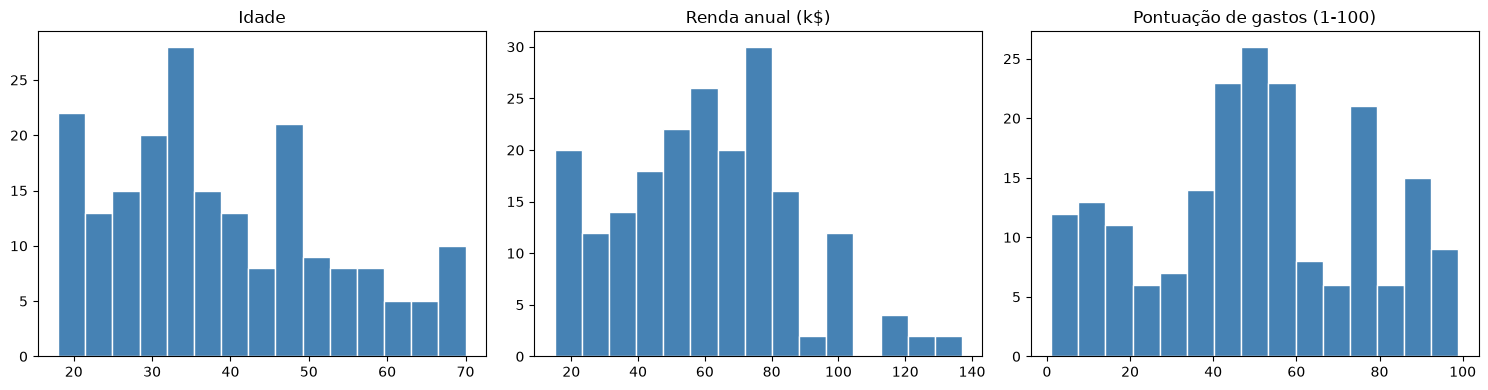

In [6]:
# Distribuição das três variáveis numéricas de interesse
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(clientes['Age'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Idade')

axes[1].hist(clientes['Annual Income (k$)'], bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('Renda anual (k$)')

axes[2].hist(clientes['Spending Score (1-100)'], bins=15, color='steelblue', edgecolor='white')
axes[2].set_title('Pontuação de gastos (1-100)')

plt.tight_layout()
plt.show()


## 4. Selecionando as variáveis para o agrupamento

Para manter o exemplo visual e didática, seguiremos o caminho tradicional deste dataset: agrupar os clientes usando **duas variáveis**:

- `Annual Income (k$)`: quanto o cliente ganha;
- `Spending Score (1-100)`: quanto ele efetivamente gasta no shopping.

Com duas dimensões conseguimos **ver** os clusters em um gráfico de dispersão, o que ajuda muito a construir intuição.

> **Nota sobre escala:** o K-Means usa distância euclidiana, então variáveis em escalas muito diferentes distorcem o resultado (a de maior magnitude domina). Aqui as duas variáveis têm faixas parecidas (15 a 137 e 1 a 99), então podemos seguir sem padronizar. Em projetos reais, padronizar com `StandardScaler` antes do K-Means é a boa prática padrão.


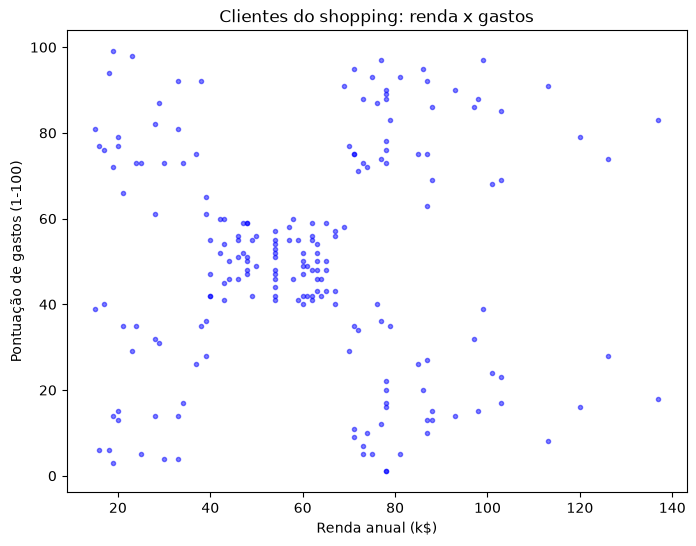

In [7]:
X = clientes[['Annual Income (k$)', 'Spending Score (1-100)']]

plt.figure(figsize=(8, 6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
            marker='.', c='blue', alpha=0.5)
plt.xlabel('Renda anual (k$)')
plt.ylabel('Pontuação de gastos (1-100)')
plt.title('Clientes do shopping: renda x gastos')
plt.show()


Mesmo antes de rodar qualquer algoritmo, o olho humano já sugere alguns agrupamentos naturais nesse gráfico. A questão é: **quantos grupos** o algoritmo deve procurar?


## 5. Quantos grupos? O método do cotovelo

O K-Means exige que a gente informe o número de clusters (K) **antes** de treinar. O método clássico para escolher K é o **método do cotovelo (elbow method)**:

1. Treinamos o K-Means para vários valores de K (aqui, de 1 a 10).
2. Para cada K, medimos a **inércia** (WCSS): a soma das distâncias quadradas de cada ponto ao centro do seu cluster.
3. A inércia sempre diminui quando K aumenta. O que procuramos é o ponto onde ela **para de cair de forma expressiva**: o "cotovelo" da curva.


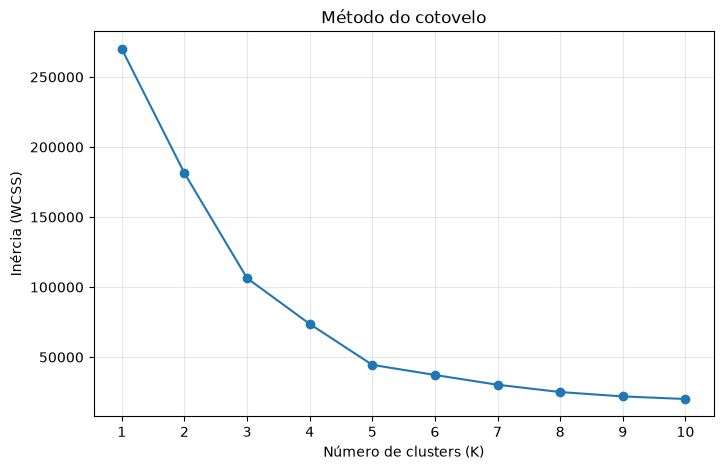

In [8]:
inercias = []
valores_k = range(1, 11)

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    modelo.fit(X)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do cotovelo')
plt.xticks(valores_k)
plt.grid(alpha=0.3)
plt.show()


A curva cai fortemente até **K = 5** e depois quase estabiliza: esse é o nosso cotovelo.


## 6. Confirmando com o coeficiente de silhueta

O cotovelo é visual e um tanto subjetivo. Uma segunda opinião numérica é o **coeficiente de silhueta**, que varia de -1 a 1 e mede, para cada ponto, se ele está mais próximo do próprio cluster (bom, perto de 1) ou do cluster vizinho (ruim, perto de 0 ou negativo).

Quanto **maior** a silhueta média, melhor a separação dos grupos.


K = 2: silhueta média = 0.297
K = 3: silhueta média = 0.468
K = 4: silhueta média = 0.493
K = 5: silhueta média = 0.554
K = 6: silhueta média = 0.540
K = 7: silhueta média = 0.529
K = 8: silhueta média = 0.455
K = 9: silhueta média = 0.456
K = 10: silhueta média = 0.441


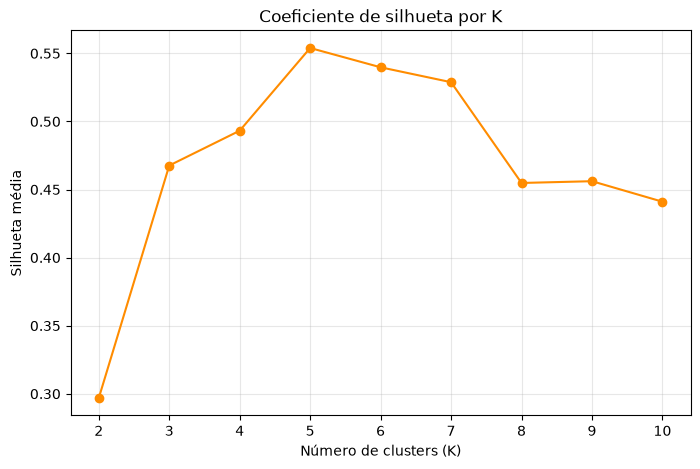

In [9]:
silhuetas = []
valores_k_sil = range(2, 11)  # silhueta precisa de pelo menos 2 clusters

for k in valores_k_sil:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    rotulos = modelo.fit_predict(X)
    score = silhouette_score(X, rotulos)
    silhuetas.append(score)
    print(f'K = {k}: silhueta média = {score:.3f}')

plt.figure(figsize=(8, 5))
plt.plot(valores_k_sil, silhuetas, marker='o', color='darkorange')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhueta média')
plt.title('Coeficiente de silhueta por K')
plt.xticks(valores_k_sil)
plt.grid(alpha=0.3)
plt.show()


As duas técnicas concordam: **K = 5** é a melhor escolha para esses dados (maior silhueta média, coincidindo com o cotovelo).


## 7. Treinando o K-Means final (K = 5)


Centroides (renda, gastos):
[[55.3 49.5]
 [86.5 82.1]
 [25.7 79.4]
 [88.2 17.1]
 [26.3 20.9]]


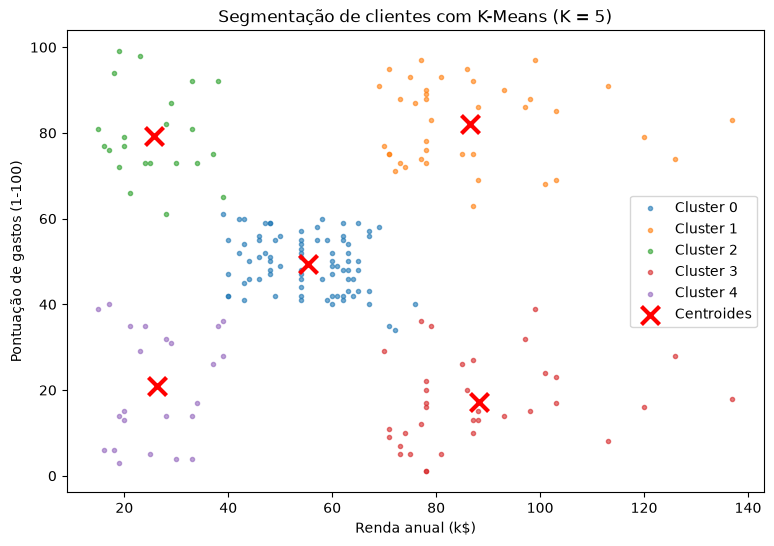

In [10]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
clientes['Cluster'] = kmeans.fit_predict(X)

centroides = kmeans.cluster_centers_
print('Centroides (renda, gastos):')
print(centroides.round(1))

plt.figure(figsize=(9, 6))
for cluster_id in sorted(clientes['Cluster'].unique()):
    grupo = clientes[clientes['Cluster'] == cluster_id]
    plt.scatter(grupo['Annual Income (k$)'], grupo['Spending Score (1-100)'],
                marker='.', alpha=0.6, label=f'Cluster {cluster_id}')

plt.scatter(centroides[:, 0], centroides[:, 1],
            marker='x', c='red', linewidths=3, s=169, label='Centroides')
plt.xlabel('Renda anual (k$)')
plt.ylabel('Pontuação de gastos (1-100)')
plt.title('Segmentação de clientes com K-Means (K = 5)')
plt.legend()
plt.show()


## 8. Interpretando os clusters como personas

Cluster só vira valor de negócio quando ganha **nome e ação**. Vamos resumir cada grupo:


In [11]:
resumo = clientes.groupby('Cluster').agg(
    qtd_clientes=('CustomerID', 'count'),
    idade_media=('Age', 'mean'),
    renda_media=('Annual Income (k$)', 'mean'),
    gasto_medio=('Spending Score (1-100)', 'mean'),
).round(1)

resumo


,qtd_clientes,idade_media,renda_media,gasto_medio
Cluster,,,,
0,81,42.7,55.3,49.5
1,39,32.7,86.5,82.1
2,22,25.3,25.7,79.4
3,35,41.1,88.2,17.1
4,23,45.2,26.3,20.9


Independentemente da numeração dos clusters (que é arbitrária e pode variar entre execuções), os cinco perfis encontrados neste dataset são sempre os mesmos:

| Persona | Renda | Gastos | Leitura de negócio |
| --- | --- | --- | --- |
| **Padrão** | média | médios | A grande massa de clientes; manter o relacionamento |
| **Alvo principal** | alta | altos | Clientes premium; programas de fidelidade e experiências VIP |
| **Potencial não explorado** | alta | baixos | Têm dinheiro mas não gastam aqui; entender o porquê e atrair com ofertas certeiras |
| **Entusiasmados** | baixa | altos | Gastam acima da renda; jovens em geral; cuidado com crédito, apostar em promoções acessíveis |
| **Econômicos** | baixa | baixos | Sensíveis a preço; campanhas de desconto e produtos de entrada |

Esse é o pulo do gato da aprendizagem não supervisionada: o algoritmo **não sabia nada de marketing** e, ainda assim, entregou uma segmentação que um time comercial reconhece na hora.


## 9. O que este exemplo ensina?

1. **Sem rótulo, sem resposta certa**: agrupamento descobre estrutura, não prevê uma variável-alvo.
2. **K é uma decisão nossa**: o algoritmo não escolhe o número de grupos sozinho; cotovelo e silhueta ajudam a decidir com critério.
3. **Escala importa**: distância euclidiana é sensível à magnitude das variáveis; padronizar é a regra geral.
4. **Cluster sem interpretação não serve**: o entregável final é a persona e a ação de negócio, não o gráfico.
5. **Visualizar constrói intuição**: com duas variáveis dá para ver o algoritmo funcionando; com mais dimensões, as mesmas ideias continuam valendo, só perdemos o desenho.

## Próximos passos possíveis

Em uma exploração mais avançada, poderíamos:

- incluir mais variáveis (idade, gênero) e padronizar com `StandardScaler`;
- comparar com outros algoritmos de agrupamento (hierárquico, DBSCAN);
- reduzir dimensões com PCA para visualizar agrupamentos com muitas variáveis;


## Fechamento para discussão em sala

> **Se classificação responde "o que é?", agrupamento responde "o que se parece com o quê?".**

Perguntas para a turma:

1. Que bases de clientes (ou produtos, ou lojas) da empresa de vocês poderiam ser segmentadas assim?
2. Se o cotovelo sugerisse K = 4 e a área de negócio insistisse em 6 segmentos, o que fazer?
3. Qual o risco de tratar a numeração dos clusters como se fosse um rótulo fixo?
4. Que ação concreta sua empresa tomaria com o grupo "renda alta, gastos baixos"?
